с kaggle был взят датасет о покупателях мола ( id , пол , возраст , доход , траты ) ( https://www.kaggle.com/datasets/shwetabh123/mall-customers )

In [48]:
import pandas as pd
import numpy as np
import kagglehub

path = kagglehub.dataset_download("shwetabh123/mall-customers")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'mall-customers' dataset.
Path to dataset files: /kaggle/input/mall-customers


используя датасет создал датафрейм , с помощью df.shape продемонстрировал его рамзеры , с помощью df.head вывел первые 5 строк ( 5 по умолчанию , если ввести df.head(10) , то выведем 10 строк )

In [49]:
df = pd.read_csv(path + "/Mall_Customers.csv")
print(df.shape)
df.head()

(200, 5)


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


df.tail() выводит 5 последних строк ( принцип такой же как у df.head())

In [50]:
df.tail()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


df.info() выводит общую информацию о таблице , df.describe() выводит статистические показатели числовых колонок

In [51]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


df.describe(include = "object") было рекомендовано затестить отдельно , видим что показывает статистику колонок с типом object

In [52]:
df.describe(include = "object")

,Genre
count,200
unique,2
top,Female
freq,112


.isnull() проверяет каждую ячейку на пустоту , .sum() суммирует , вместе получаем .isnull().sum() количество пустых ячеек

In [53]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


df.dropna() удаляет пропуски


In [54]:
df.dropna()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


посчитал значение , того , чего есть смысл считать

In [55]:
# возраст
mean_age = df['Age'].mean()
median_age = df['Age'].median()
mode_age = df['Age'].mode()[0]

# доход
mean_income = df['Annual Income (k$)'].mean()
median_income = df['Annual Income (k$)'].median()
mode_income = df['Annual Income (k$)'].mode()

# траты
mean_score = df['Spending Score (1-100)'].mean()
median_score = df['Spending Score (1-100)'].median()
mode_score = df['Spending Score (1-100)'].mode()

In [56]:
stats_df = pd.DataFrame({
    'Показатель': ['mean', 'median', 'mode'],
    'Age': [mean_age, median_age, mode_age],
    'Annual Income': [mean_income, median_income, mode_income],
    'Spending Score': [mean_score, median_score, mode_score]
})
display(stats_df)

,Показатель,Age,Annual Income,Spending Score
0,mean,38.85,60.56,50.2
1,median,36.00,61.5,50.0
2,mode,32.00,"0 54 1 78 Name: Annual Income (k$), dtyp...","0 42 Name: Spending Score (1-100), dtype: i..."


In [57]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis

stat_names = [
    'Min', 'Max', 'Mean', 'Median', 'Mode',
    '5%', '25%', '50%', '75%', '95%',
    'Variance', 'Skewness', 'Kurtosis'
]

stats_df = pd.DataFrame(index=stat_names)

stats_df['Age'] = [
    df['Age'].min(),
    df['Age'].max(),
    df['Age'].mean(),
    df['Age'].median(),
    df['Age'].mode()[0],
    df['Age'].quantile(0.05),
    df['Age'].quantile(0.25),
    df['Age'].quantile(0.5),
    df['Age'].quantile(0.75),
    df['Age'].quantile(0.95),
    df['Age'].var(),
    skew(df['Age']),
    kurtosis(df['Age'])
]

stats_df['Annual Income'] = [
    df['Annual Income (k$)'].min(),
    df['Annual Income (k$)'].max(),
    df['Annual Income (k$)'].mean(),
    df['Annual Income (k$)'].median(),
    df['Annual Income (k$)'].mode()[0],
    df['Annual Income (k$)'].quantile(0.05),
    df['Annual Income (k$)'].quantile(0.25),
    df['Annual Income (k$)'].quantile(0.5),
    df['Annual Income (k$)'].quantile(0.75),
    df['Annual Income (k$)'].quantile(0.95),
    df['Annual Income (k$)'].var(),
    skew(df['Annual Income (k$)']),
    kurtosis(df['Annual Income (k$)'])
]

stats_df['Spending Score'] = [
    df['Spending Score (1-100)'].min(),
    df['Spending Score (1-100)'].max(),
    df['Spending Score (1-100)'].mean(),
    df['Spending Score (1-100)'].median(),
    df['Spending Score (1-100)'].mode()[0],
    df['Spending Score (1-100)'].quantile(0.05),
    df['Spending Score (1-100)'].quantile(0.25),
    df['Spending Score (1-100)'].quantile(0.5),
    df['Spending Score (1-100)'].quantile(0.75),
    df['Spending Score (1-100)'].quantile(0.95),
    df['Spending Score (1-100)'].var(),
    skew(df['Spending Score (1-100)']),
    kurtosis(df['Spending Score (1-100)'])
]


print("📊 DataFrame со статистикой:")
print(stats_df)

📊 DataFrame со статистикой:
                 Age  Annual Income  Spending Score
Min        18.000000      15.000000        1.000000
Max        70.000000     137.000000       99.000000
Mean       38.850000      60.560000       50.200000
Median     36.000000      61.500000       50.000000
Mode       32.000000      54.000000       42.000000
5%         19.000000      19.000000        6.000000
25%        28.750000      41.500000       34.750000
50%        36.000000      61.500000       50.000000
75%        49.000000      78.000000       73.000000
95%        66.050000     103.000000       92.000000
Variance  195.133166     689.835578      666.854271
Skewness    0.481919       0.319424       -0.046865
Kurtosis   -0.684751      -0.125893       -0.835958


one-hot encoding это мед преобразования категориональных данных , я создал отдельные столбцы для женщин и мужчин , где показывается , мужчина это или женщина , с помощью булевых значений

In [58]:

df_encoded = pd.get_dummies(df, columns=['Genre'], prefix='Genre', drop_first=False)
print(df_encoded.head(10))

   CustomerID  Age  Annual Income (k$)  Spending Score (1-100)  Genre_Female  \
0           1   19                  15                      39         False   
1           2   21                  15                      81         False   
2           3   20                  16                       6          True   
3           4   23                  16                      77          True   
4           5   31                  17                      40          True   
5           6   22                  17                      76          True   
6           7   35                  18                       6          True   
7           8   23                  18                      94          True   
8           9   64                  19                       3         False   
9          10   30                  19                      72          True   

   Genre_Male  
0        True  
1        True  
2       False  
3       False  
4       False  
5       False  
6      

label encoding это метод преобразовния отдельных признаков в числовые значения , в моей таблице мужчина=1 , женщина=0

In [59]:

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.feature_extraction import FeatureHasher

df_label = df.copy()
label_encoder = LabelEncoder()

df_label['Genre_Label'] = label_encoder.fit_transform(df_label['Genre'])

print(df_label[['Genre', 'Genre_Label']].head(10))

print("\nСоответствие:")
for genre, label in zip(df_label['Genre'].unique(), label_encoder.transform(df_label['Genre'].unique())):
    print(f"{genre} → {label}")

    Genre  Genre_Label
0    Male            1
1    Male            1
2  Female            0
3  Female            0
4  Female            0
5  Female            0
6  Female            0
7  Female            0
8    Male            1
9  Female            0

Соответствие:
Male → 1
Female → 0


In [60]:

from sklearn.feature_extraction import FeatureHasher

np.random.seed(42)
cities = ['NYC', 'LA', 'Chicago', 'Houston', 'Phoenix', 'Miami', 'Seattle', 'Boston']
df_hash = df.copy()
df_hash['City'] = np.random.choice(cities, size=len(df_hash))

print("Искусственная колонка 'City' (для демонстрации):")
print(df_hash['City'].value_counts())

hashing_encoder = FeatureHasher(n_features=4, input_type='string')
city_hashed = hashing_encoder.fit_transform(df_hash[['City']].astype(str).values)

city_hash_df = pd.DataFrame(
    city_hashed.toarray(),
    columns=[f'City_hash_{i}' for i in range(4)]
)

print("\nРезультат Feature Hashing (4 новых признака):")
print(city_hash_df.head(10))

Искусственная колонка 'City' (для демонстрации):
City
Seattle    31
Houston    30
LA         25
Boston     24
Chicago    23
Phoenix    23
NYC        23
Miami      21
Name: count, dtype: int64

Результат Feature Hashing (4 новых признака):
   City_hash_0  City_hash_1  City_hash_2  City_hash_3
0          0.0          0.0         -1.0          0.0
1          0.0          1.0          0.0          0.0
2          1.0          0.0          0.0          0.0
3          0.0          0.0         -1.0          0.0
4          0.0          0.0          1.0          0.0
5          0.0         -1.0          0.0          0.0
6          1.0          0.0          0.0          0.0
7          1.0          0.0          0.0          0.0
8          0.0          0.0         -1.0          0.0
9          0.0          0.0         -1.0          0.0


In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

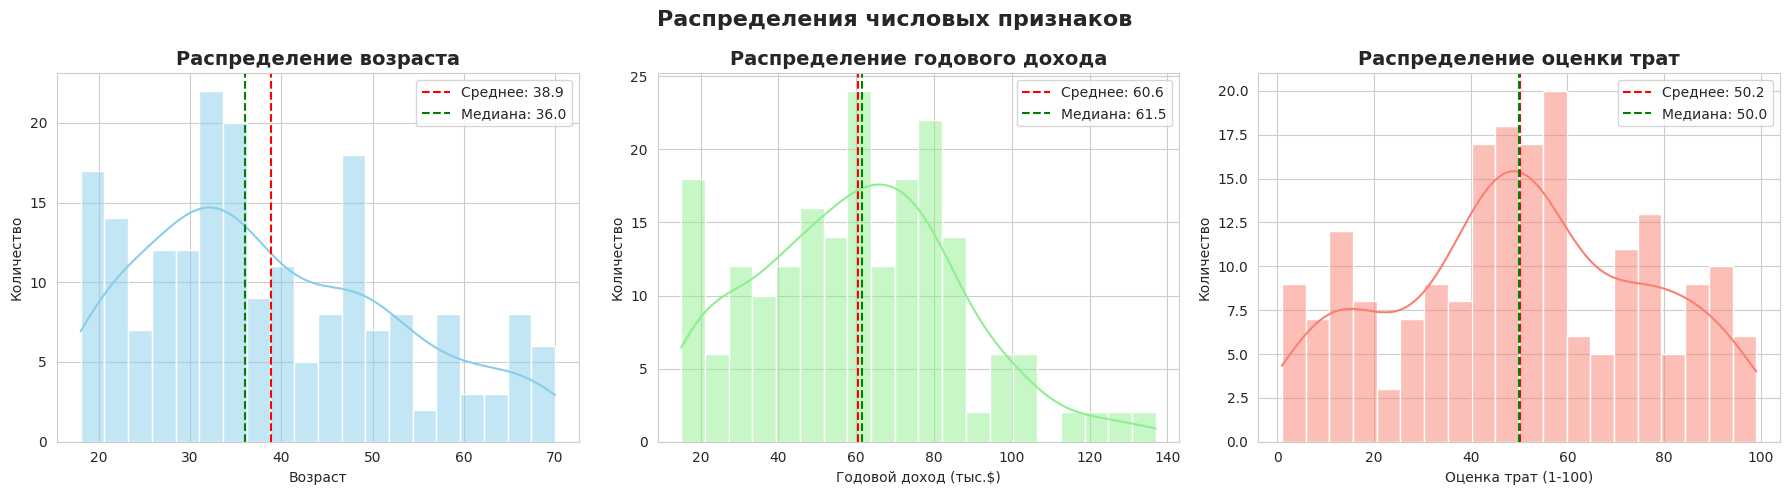

In [62]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Age'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Распределение возраста', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Возраст')
axes[0].set_ylabel('Количество')
axes[0].axvline(df['Age'].mean(), color='red', linestyle='--', label=f'Среднее: {df["Age"].mean():.1f}')
axes[0].axvline(df['Age'].median(), color='green', linestyle='--', label=f'Медиана: {df["Age"].median():.1f}')
axes[0].legend()

sns.histplot(df['Annual Income (k$)'], bins=20, kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Распределение годового дохода', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Годовой доход (тыс.$)')
axes[1].set_ylabel('Количество')
axes[1].axvline(df['Annual Income (k$)'].mean(), color='red', linestyle='--',
                label=f'Среднее: {df["Annual Income (k$)"].mean():.1f}')
axes[1].axvline(df['Annual Income (k$)'].median(), color='green', linestyle='--',
                label=f'Медиана: {df["Annual Income (k$)"].median():.1f}')
axes[1].legend()

sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Распределение оценки трат', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Оценка трат (1-100)')
axes[2].set_ylabel('Количество')
axes[2].axvline(df['Spending Score (1-100)'].mean(), color='red', linestyle='--',
                label=f'Среднее: {df["Spending Score (1-100)"].mean():.1f}')
axes[2].axvline(df['Spending Score (1-100)'].median(), color='green', linestyle='--',
                label=f'Медиана: {df["Spending Score (1-100)"].median():.1f}')
axes[2].legend()

plt.suptitle('Распределения числовых признаков', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

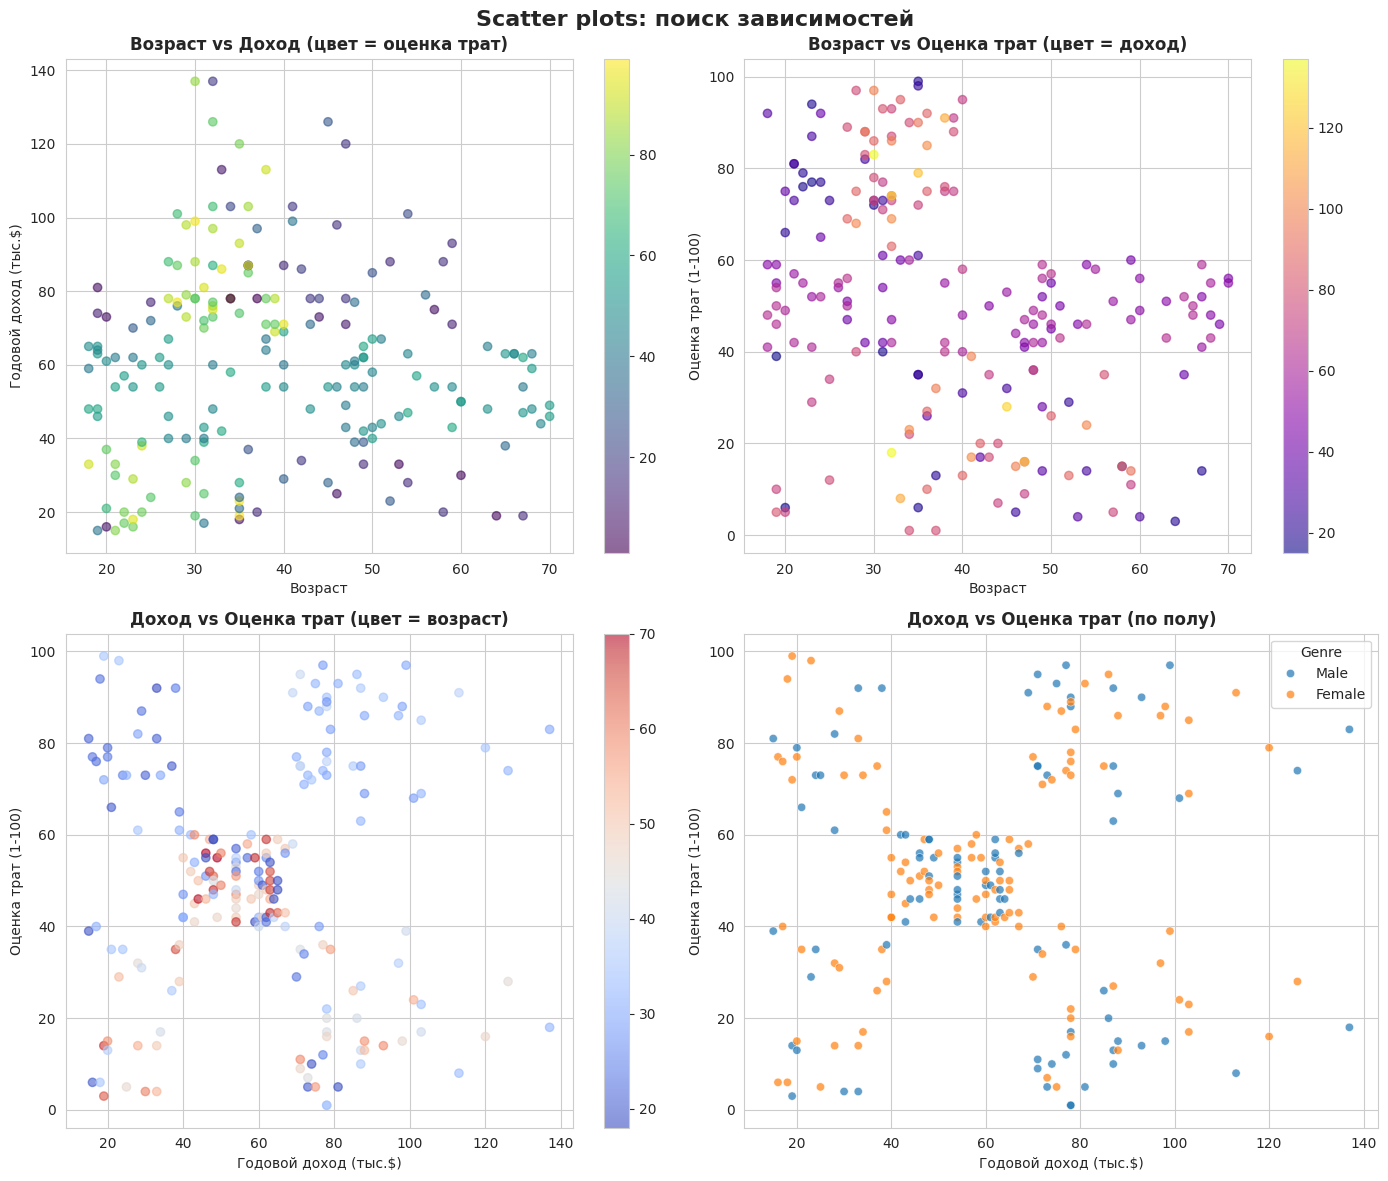

In [63]:

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

scatter1 = axes[0, 0].scatter(df['Age'], df['Annual Income (k$)'],
                              c=df['Spending Score (1-100)'], cmap='viridis', alpha=0.6)
axes[0, 0].set_title('Возраст vs Доход (цвет = оценка трат)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Возраст')
axes[0, 0].set_ylabel('Годовой доход (тыс.$)')
plt.colorbar(scatter1, ax=axes[0, 0])

scatter2 = axes[0, 1].scatter(df['Age'], df['Spending Score (1-100)'],
                              c=df['Annual Income (k$)'], cmap='plasma', alpha=0.6)
axes[0, 1].set_title('Возраст vs Оценка трат (цвет = доход)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Возраст')
axes[0, 1].set_ylabel('Оценка трат (1-100)')
plt.colorbar(scatter2, ax=axes[0, 1])

scatter3 = axes[1, 0].scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
                              c=df['Age'], cmap='coolwarm', alpha=0.6)
axes[1, 0].set_title('Доход vs Оценка трат (цвет = возраст)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Годовой доход (тыс.$)')
axes[1, 0].set_ylabel('Оценка трат (1-100)')
plt.colorbar(scatter3, ax=axes[1, 0])

sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Genre', alpha=0.7, ax=axes[1, 1])
axes[1, 1].set_title('Доход vs Оценка трат (по полу)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Годовой доход (тыс.$)')
axes[1, 1].set_ylabel('Оценка трат (1-100)')

plt.suptitle('Scatter plots: поиск зависимостей', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

box plot

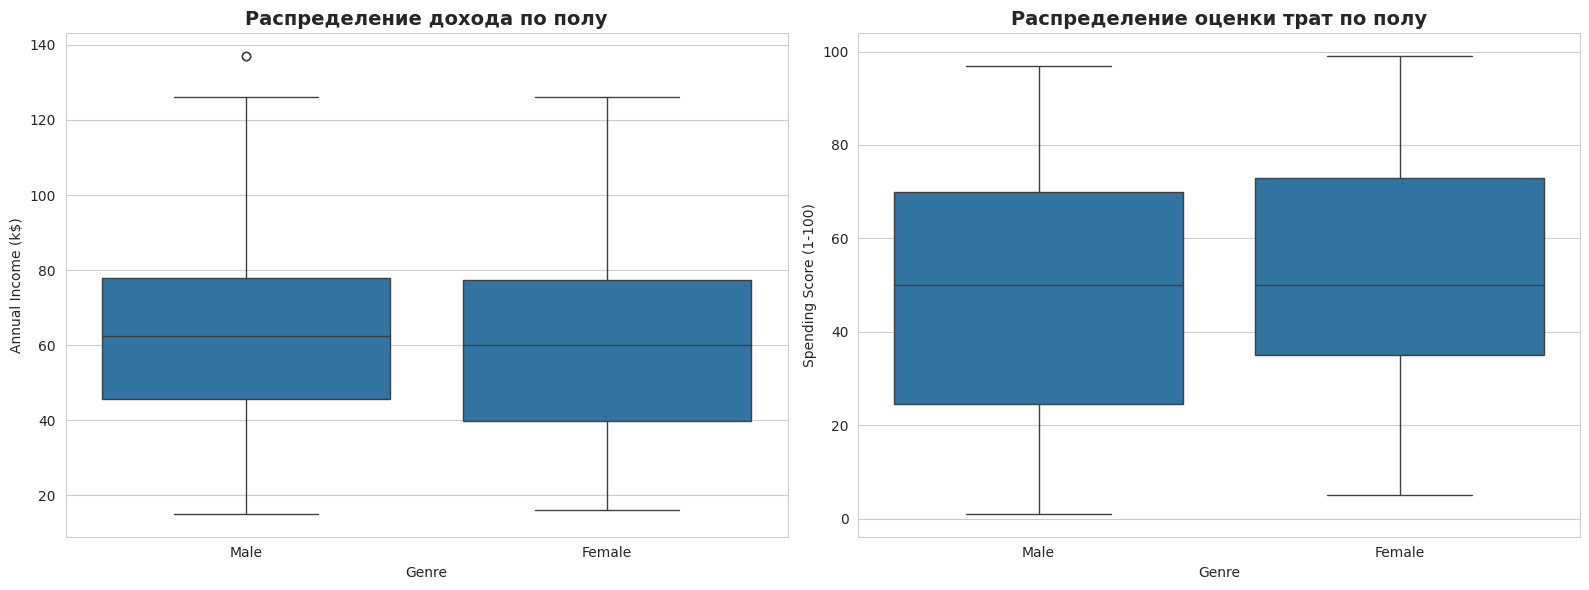

In [64]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='Genre', y='Annual Income (k$)', ax=axes[0])
axes[0].set_title('Распределение дохода по полу', fontsize=14, fontweight='bold')

sns.boxplot(data=df, x='Genre', y='Spending Score (1-100)', ax=axes[1])
axes[1].set_title('Распределение оценки трат по полу', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

bar/count plot

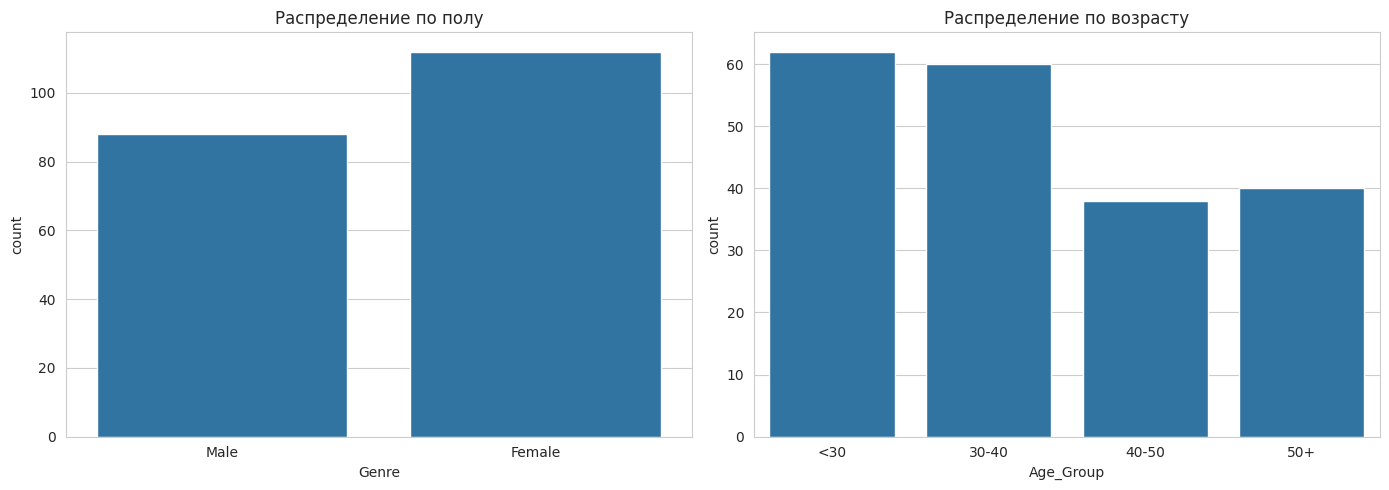

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='Genre', ax=axes[0])
axes[0].set_title('Распределение по полу')

df['Age_Group'] = pd.cut(df['Age'], bins=[0, 30, 40, 50, 100], labels=['<30', '30-40', '40-50', '50+'])
sns.countplot(data=df, x='Age_Group', ax=axes[1])
axes[1].set_title('Распределение по возрасту')

plt.tight_layout()
plt.show()

heatmap

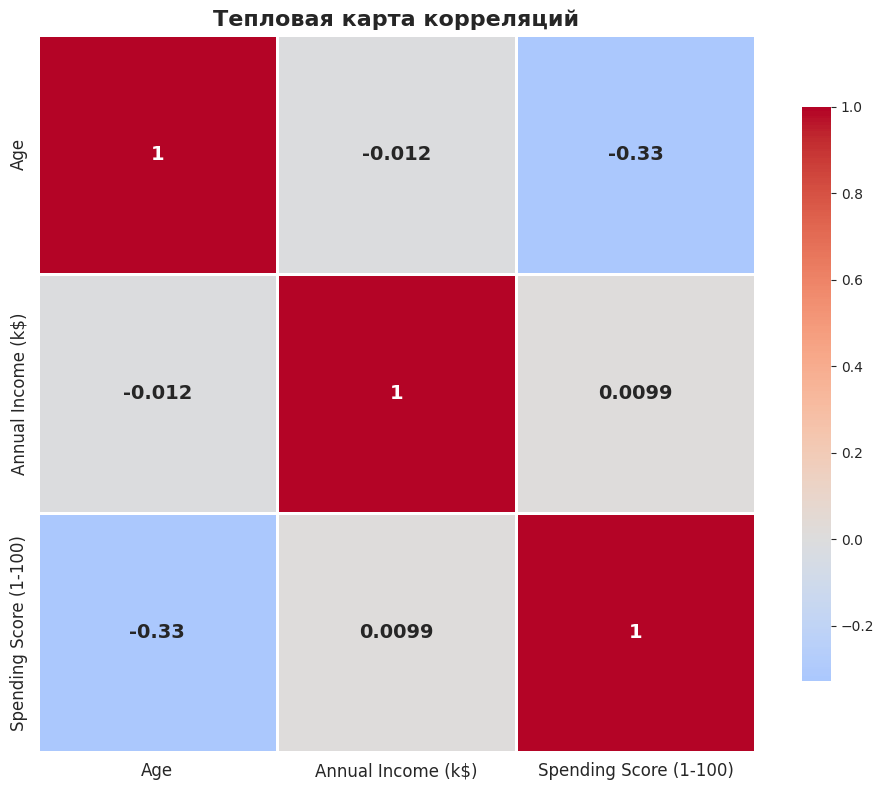

                          Age  Annual Income (k$)  Spending Score (1-100)
Age                     1.000              -0.012                  -0.327
Annual Income (k$)     -0.012               1.000                   0.010
Spending Score (1-100) -0.327               0.010                   1.000


In [66]:

numeric_df = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 14, "fontweight": "bold"})
plt.title('Тепловая карта корреляций', fontsize=16, fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

print(correlation_matrix.round(3))

использовал deepseek в своей работе . с помощью него разбирался со всем , потому что никогда не занимался ничем подобным